<a href="https://colab.research.google.com/github/Sayandt-web/KNN-Cluster-Validity/blob/main/KNN_Cluster_Validity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib . pyplot as plt

from sklearn . cluster import KMeans
from sklearn . datasets import make_blobs
from sklearn . preprocessing import StandardScaler
from sklearn . metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [ ]:
X , y_true = make_blobs (
    n_samples =500 ,
    centers =4 ,
    cluster_std =0.9 ,
    random_state =42
)

# Standardize the data
scaler = StandardScaler ()
X = scaler . fit_transform ( X)

In [ ]:
K_range = range(2, 11)

wcss = []
sil_scores = []
db_scores = []
ch_scores = []

print("=" * 75)
print("K-MEANS CLUSTER VALIDITY ANALYSIS ")
print("=" * 75)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++', # Corrected from ’k-means ++ ’
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

    print(
        f"k = {k:2d} | "
        f" WCSS = {km.inertia_:8.2f} | "
        f" Silhouette = {sil_scores[-1]:.4f} | "
        f" Davies - Bouldin = {db_scores[-1]:.4f} | "
        f" Calinski - Harabasz = {ch_scores[-1]:.2f}"
    )

K-MEANS CLUSTER VALIDITY ANALYSIS 
k =  2 |  WCSS = 15551.96 |  Silhouette = 0.6014 |  Davies - Bouldin = 0.5098 |  Calinski - Harabasz = 580.63
k =  3 |  WCSS =  3266.09 |  Silhouette = 0.7717 |  Davies - Bouldin = 0.3381 |  Calinski - Harabasz = 2314.37
k =  4 |  WCSS =   768.60 |  Silhouette = 0.8124 |  Davies - Bouldin = 0.2639 |  Calinski - Harabasz = 7080.50
k =  5 |  WCSS =   693.32 |  Silhouette = 0.6825 |  Davies - Bouldin = 0.6160 |  Calinski - Harabasz = 5888.76
k =  6 |  WCSS =   623.14 |  Silhouette = 0.5497 |  Davies - Bouldin = 0.8729 |  Calinski - Harabasz = 5241.89
k =  7 |  WCSS =   554.46 |  Silhouette = 0.4489 |  Davies - Bouldin = 1.0025 |  Calinski - Harabasz = 4909.61
k =  8 |  WCSS =   481.09 |  Silhouette = 0.3467 |  Davies - Bouldin = 1.1283 |  Calinski - Harabasz = 4850.85
k =  9 |  WCSS =   442.90 |  Silhouette = 0.3470 |  Davies - Bouldin = 1.0592 |  Calinski - Harabasz = 4606.45
k = 10 |  WCSS =   401.02 |  Silhouette = 0.3576 |  Davies - Bouldin = 0.9836 

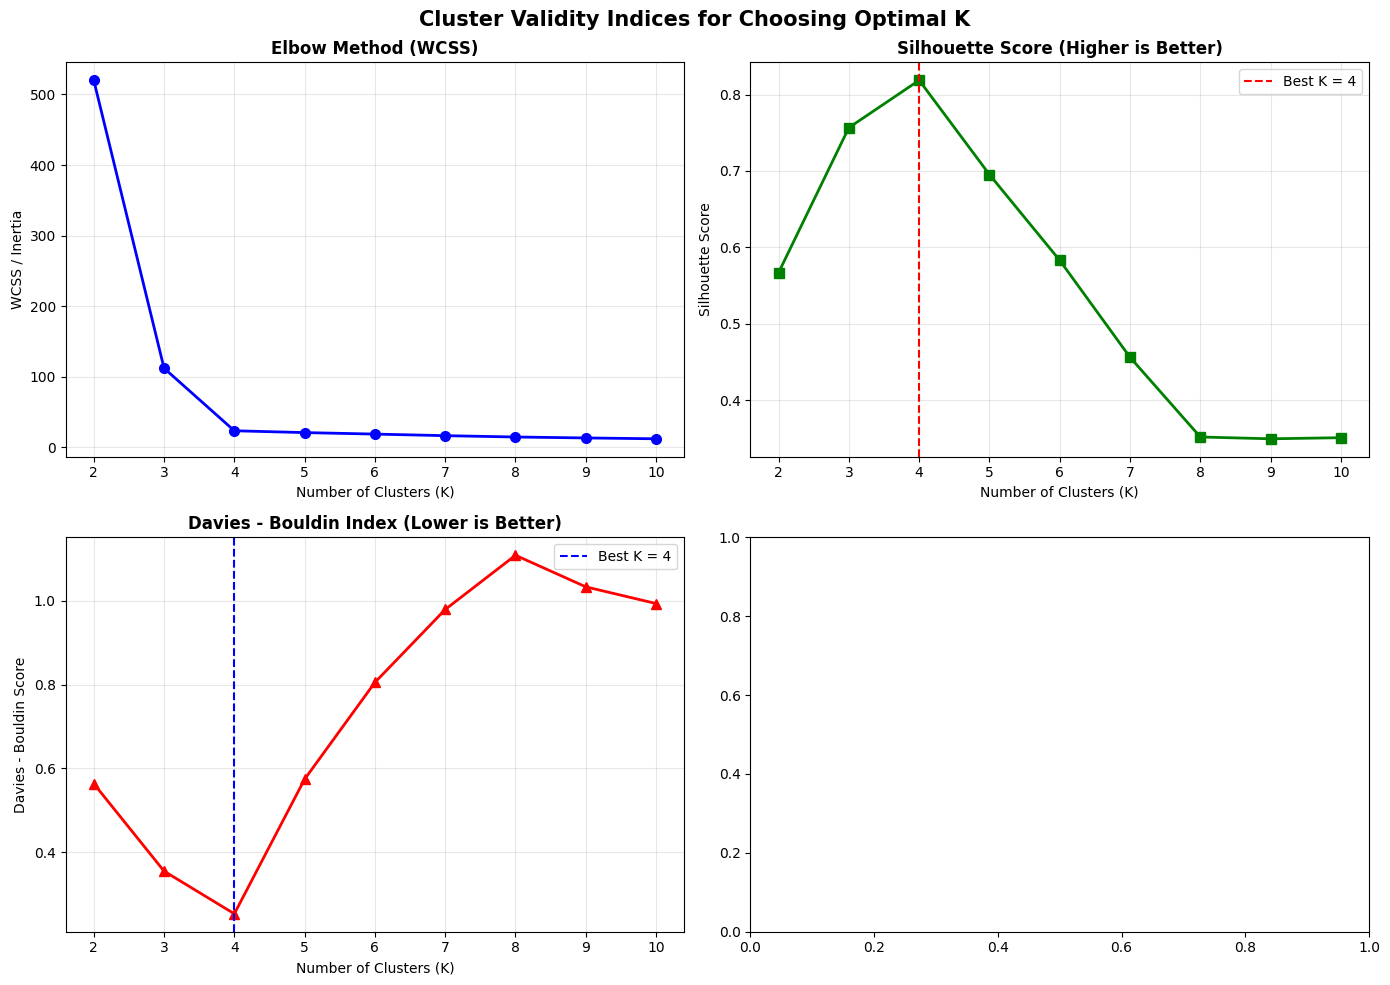

In [ ]:
K_list = list(K_range)
best_sil_k = K_list[np.argmax(sil_scores)]
best_db_k = K_list[np.argmin(db_scores)]
best_ch_k = K_list[np.argmax(ch_scores)]

# ============================================================
# PLOT RESULTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Elbow Method
axes[0, 0].plot(K_list, wcss, 'bo-', linewidth=2, markersize=7)
axes[0, 0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS / Inertia')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette Score
axes[0, 1].plot(K_list, sil_scores, 'gs-', linewidth=2, markersize=7)
axes[0, 1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best K = {best_sil_k}')
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Davies - Bouldin Index
axes[1, 0].plot(K_list, db_scores, 'r^-', linewidth=2, markersize=7)
axes[1, 0].axvline(best_db_k, color='blue', linestyle='--', label=f'Best K = {best_db_k}')
axes[1, 0].set_title('Davies - Bouldin Index (Lower is Better)', fontweight='bold')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Davies - Bouldin Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
plt.suptitle('Cluster Validity Indices for Choosing Optimal K',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print ("\n" + "=" * 60)
print (" FINAL RECOMMENDATION ")
print ("=" * 60)
print ( f" Best K by Silhouette Score : { best_sil_k }")
print ( f" Best K by Davies - Bouldin Index : { best_db_k }")
print ( f" Best K by Calinski - Harabasz : { best_ch_k }")
print (" Elbow Method : Inspect graph visually ")
print ("=" * 60)

if best_sil_k == best_db_k == best_ch_k :
    print (f" Consensus suggests optimal K = { best_sil_k }")
else :
    print (" Different indices suggest different K values .")
    print (" Choose K by combining metric values and elbow plot interpretation .")


 FINAL RECOMMENDATION 
 Best K by Silhouette Score : 4
 Best K by Davies - Bouldin Index : 4
 Best K by Calinski - Harabasz : 4
 Elbow Method : Inspect graph visually 
 Consensus suggests optimal K = 4


K-MEANS CLUSTER VALIDITY ANALYSIS 
k =  2 |  WCSS =   520.12 |  Silhouette = 0.5669 |  Davies - Bouldin = 0.5638 |  Calinski - Harabasz = 459.48
k =  3 |  WCSS =   112.08 |  Silhouette = 0.7567 |  Davies - Bouldin = 0.3550 |  Calinski - Harabasz = 1968.65
k =  4 |  WCSS =    23.47 |  Silhouette = 0.8187 |  Davies - Bouldin = 0.2532 |  Calinski - Harabasz = 6878.92
k =  5 |  WCSS =    21.23 |  Silhouette = 0.6881 |  Davies - Bouldin = 0.6200 |  Calinski - Harabasz = 5706.32
k =  6 |  WCSS =    18.89 |  Silhouette = 0.5776 |  Davies - Bouldin = 0.8287 |  Calinski - Harabasz = 5132.35
k =  7 |  WCSS =    17.21 |  Silhouette = 0.4641 |  Davies - Bouldin = 1.0184 |  Calinski - Harabasz = 4694.06
k =  8 |  WCSS =    14.86 |  Silhouette = 0.3311 |  Davies - Bouldin = 1.1519 |  Calinski - Harabasz = 4661.35
k =  9 |  WCSS =    13.59 |  Silhouette = 0.3325 |  Davies - Bouldin = 1.0781 |  Calinski - Harabasz = 4454.97
k = 10 |  WCSS =    12.29 |  Silhouette = 0.3477 |  Davies - Bouldin = 1.0023 

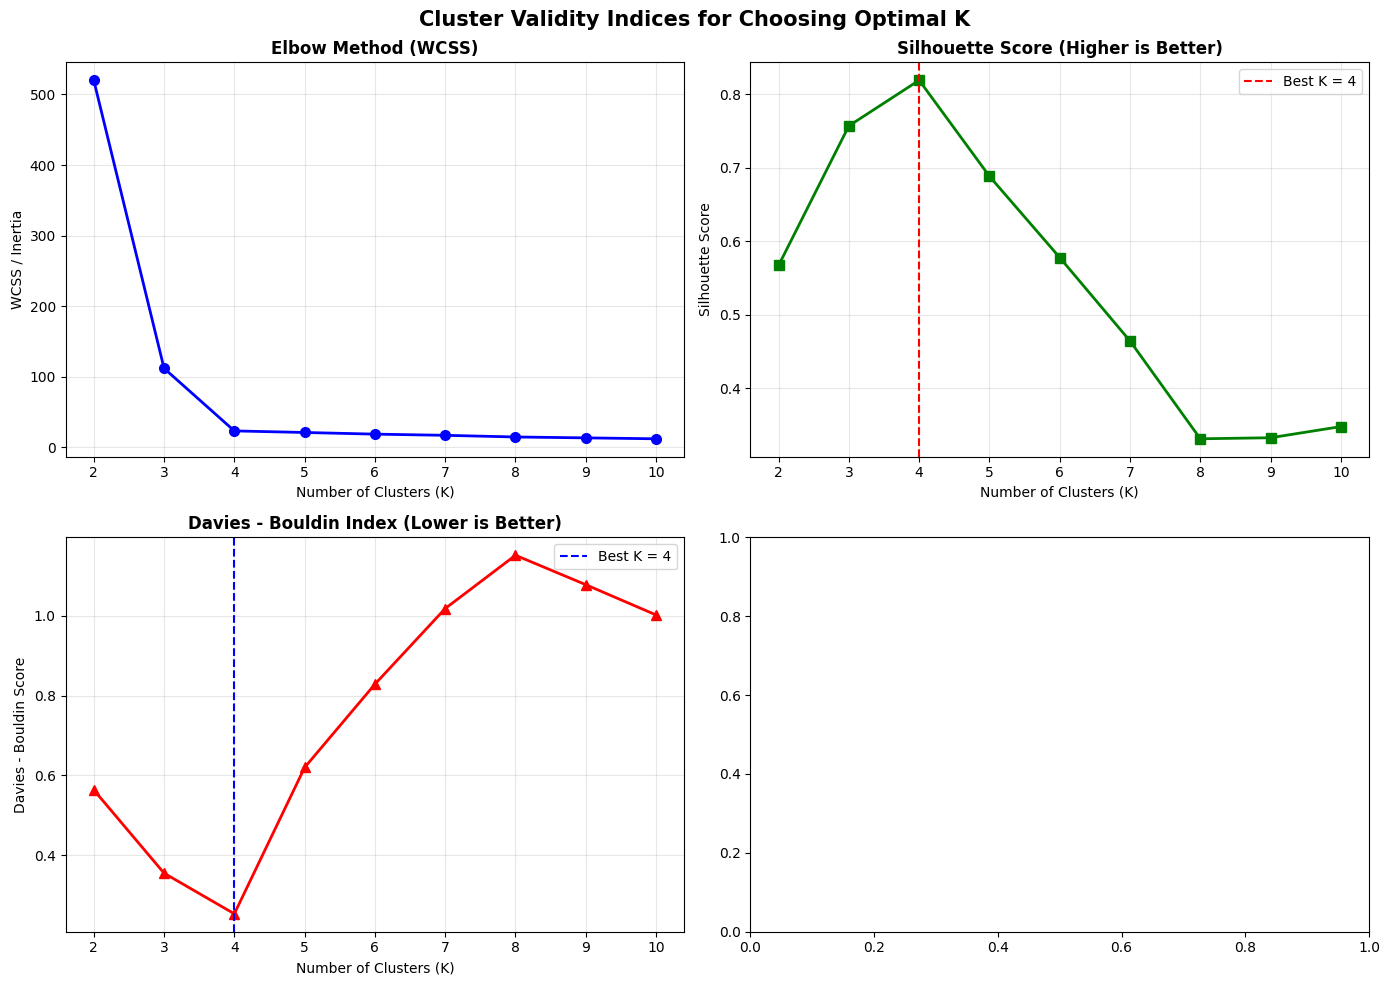


 FINAL RECOMMENDATION 
 Best K by Silhouette Score : 4
 Best K by Davies - Bouldin Index : 4
 Best K by Calinski - Harabasz : 4
 Elbow Method : Inspect graph visually 
 Consensus suggests optimal K = 4


In [ ]:
import numpy as np
import matplotlib . pyplot as plt

from sklearn . cluster import KMeans
from sklearn . datasets import make_blobs
from sklearn . preprocessing import StandardScaler
from sklearn . metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
X , y_true = make_blobs (
    n_samples =500 ,
    centers =4 ,
    cluster_std =0.9 ,
    random_state =42
)

# Standardize the data
scaler = StandardScaler ()
X = scaler . fit_transform ( X)
K_range = range(2, 11)

wcss = []
sil_scores = []
db_scores = []
ch_scores = []

print("=" * 75)
print("K-MEANS CLUSTER VALIDITY ANALYSIS ")
print("=" * 75)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='random', # Corrected from ’random means’
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

    print(
        f"k = {k:2d} | "
        f" WCSS = {km.inertia_:8.2f} | "
        f" Silhouette = {sil_scores[-1]:.4f} | "
        f" Davies - Bouldin = {db_scores[-1]:.4f} | "
        f" Calinski - Harabasz = {ch_scores[-1]:.2f}"
    )
    K_list = list(K_range)
best_sil_k = K_list[np.argmax(sil_scores)]
best_db_k = K_list[np.argmin(db_scores)]
best_ch_k = K_list[np.argmax(ch_scores)]

# ============================================================
# PLOT RESULTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Elbow Method
axes[0, 0].plot(K_list, wcss, 'bo-', linewidth=2, markersize=7)
axes[0, 0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS / Inertia')
axes[0, 0].grid(True, alpha=0.3)

# 2. Silhouette Score
axes[0, 1].plot(K_list, sil_scores, 'gs-', linewidth=2, markersize=7)
axes[0, 1].axvline(best_sil_k, color='red', linestyle='--', label=f'Best K = {best_sil_k}')
axes[0, 1].set_title('Silhouette Score (Higher is Better)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Davies - Bouldin Index
axes[1, 0].plot(K_list, db_scores, 'r^-', linewidth=2, markersize=7)
axes[1, 0].axvline(best_db_k, color='blue', linestyle='--', label=f'Best K = {best_db_k}')
axes[1, 0].set_title('Davies - Bouldin Index (Lower is Better)', fontweight='bold')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Davies - Bouldin Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
plt.suptitle('Cluster Validity Indices for Choosing Optimal K',
    fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print ("\n" + "=" * 60)
print (" FINAL RECOMMENDATION ")
print ("=" * 60)
print ( f" Best K by Silhouette Score : { best_sil_k }")
print ( f" Best K by Davies - Bouldin Index : { best_db_k }")
print ( f" Best K by Calinski - Harabasz : { best_ch_k }")
print (" Elbow Method : Inspect graph visually ")
print ("=" * 60)

if best_sil_k == best_db_k == best_ch_k :
    print (f" Consensus suggests optimal K = { best_sil_k }")
else :
    print (" Different indices suggest different K values .")
    print (" Choose K by combining metric values and elbow plot interpretation .")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn . cluster import KMeans
from sklearn . datasets import make_blobs
from sklearn . preprocessing import StandardScaler
from sklearn . metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [ ]:
X , y_true = make_blobs (
    n_samples =500 ,
    centers =4 ,
    cluster_std =0.9 ,
    random_state =42
)